# Scenario 1 – Occupancy Estimation and People Counter Correction

## Objective

This scenario investigates whether environmental, operational and temporal measurements can support the estimation of indoor occupancy.

The methodology is first developed and evaluated in Room 4.9 using occupied desks as the reference target. The same modelling framework is then evaluated independently in Room 2.3 using the Workplace Occupancy people count as reference data.

Finally, the trained occupancy estimation model is applied to Room 3.9 to support the identification and correction of inconsistencies in the available People Counter measurements.

The resulting corrected occupancy estimate is intended as an operationally improved occupancy indicator rather than as a direct ground-truth measurement.

In [1]:
# IMPORTS AND NOTEBOOK CONFIGURATION


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor,
    RandomForestClassifier
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Pandas display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

# Plot configuration
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

## 1. Occupancy Estimation in Room 4.9

Room 4.9 is used as the primary environment for developing the occupancy estimation methodology. The number of occupied desks is used as the reference target, while environmental, operational and temporal measurements are used as input features.

The modelling dataset includes current environmental measurements together with temporal characteristics and CO₂-derived dynamic features, including short-term change, lagged measurements and a 30-minute rolling mean.

In [2]:
# LOAD DATASET — ROOM 4.9


df = pd.read_csv("room_4_9_full_dataset.csv")

# Convert timestamp column to datetime
df["ts"] = pd.to_datetime(
    df["ts"],
    errors="coerce"
)

# Ensure valid chronological ordering
df = (
    df
    .dropna(subset=["ts"])
    .sort_values("ts")
    .reset_index(drop=True)
)

print("Room 4.9 dataset loaded successfully.")
print()
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(
    "Time range:",
    df["ts"].min(),
    "→",
    df["ts"].max()
)

display(df.head())

Room 4.9 dataset loaded successfully.

Rows: 38692
Columns: 59
Time range: 2025-09-01 20:40:00 → 2026-06-05 06:50:00


,ts,co2_iaq1,temperature_iaq1,humidity_iaq1,light_level_iaq1,pir_iaq1,co2_iaq2,temperature_iaq2,humidity_iaq2,light_level_iaq2,pir_iaq2,co2_avg,temperature_avg,humidity_avg,light_level_avg,pir_any,available_iaq_sensors,desk_1,desk_2,desk_3,desk_4,desk_5,desk_6,desk_7,desk_8,desk_9,desk_10,desk_11,desk_12,desk_13,desk_14,desk_15,desk_16,desk_17,desk_18,desk_19,desk_20,desk_21,desk_22,desk_23,desk_24,desk_25,desk_26,desk_27,desk_28,desk_29,desk_30,desk_31,desk_32,occupied_desks,free_desks,occupancy_rate,any_desk_occupied,mc_1,mc_2,mc_3,mc_4,open_windows,open_windows_binary
0,2025-09-01 20:40:00,583.0,29.3,42.5,0.0,0.0,577.0,29.2,42.5,0.0,0.0,580.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
1,2025-09-01 20:50:00,580.0,29.3,42.5,0.0,0.0,575.0,29.2,42.5,0.0,0.0,577.5,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
2,2025-09-01 21:00:00,577.0,29.3,42.5,0.0,0.0,571.0,29.2,42.5,0.0,0.0,574.0,29.25,42.50,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
3,2025-09-01 21:10:00,572.0,29.3,42.5,0.0,0.0,566.0,29.2,43.0,0.0,0.0,569.0,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1
4,2025-09-01 21:20:00,568.0,29.3,42.5,0.0,0.0,561.0,29.2,43.0,0.0,0.0,564.5,29.25,42.75,0.0,0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,32,0.0,0,1,0,0,0,1,1


In [3]:
# FEATURE ENGINEERING — ROOM 4.9


# Temporal features
df["hour"] = df["ts"].dt.hour
df["day_of_week"] = df["ts"].dt.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

# Cyclical representation of hour
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

# Cyclical representation of day of week
df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

# CO₂ rate of change over one 10-minute interval
df["co2_change_10min"] = (
    df["co2_avg"].diff()
)

# Lagged CO₂ values
df["co2_lag_1"] = (
    df["co2_avg"].shift(1)
)

df["co2_lag_2"] = (
    df["co2_avg"].shift(2)
)

df["co2_lag_3"] = (
    df["co2_avg"].shift(3)
)

# Rolling mean of the previous 30 minutes
df["co2_rolling_mean_30min"] = (
    df["co2_avg"]
    .shift(1)
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

In [4]:
# MODEL DATASET — ROOM 4.9


feature_columns = [
    "co2_avg",
    "co2_change_10min",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_rolling_mean_30min",
    "temperature_avg",
    "humidity_avg",
    "light_level_avg",
    "pir_any",
    "open_windows",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]

target_column = "occupied_desks"

model_df = (
    df[
        ["ts"]
        + feature_columns
        + [target_column]
    ]
    .dropna()
    .copy()
)

print("Room 4.9 model dataset created successfully.")
print()
print("Rows:", model_df.shape[0])
print("Columns:", model_df.shape[1])

print("\nTarget distribution:")
print(
    model_df[target_column]
    .describe()
    .round(2)
)

display(model_df.head())

Room 4.9 model dataset created successfully.

Rows: 38689
Columns: 18

Target distribution:
count    38689.00
mean         1.34
std          4.63
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         32.00
Name: occupied_desks, dtype: float64


,ts,co2_avg,co2_change_10min,co2_lag_1,co2_lag_2,co2_lag_3,co2_rolling_mean_30min,temperature_avg,humidity_avg,light_level_avg,pir_any,open_windows,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,occupied_desks
3,2025-09-01 21:10:00,569.0,-5.0,574.0,577.5,580.0,577.166667,29.25,42.75,0.0,0,1,-0.707107,0.707107,0.0,1.0,0,0
4,2025-09-01 21:20:00,564.5,-4.5,569.0,574.0,577.5,573.500000,29.25,42.75,0.0,0,1,-0.707107,0.707107,0.0,1.0,0,0
5,2025-09-01 21:30:00,563.0,-1.5,564.5,569.0,574.0,569.166667,29.25,42.50,0.0,0,1,-0.707107,0.707107,0.0,1.0,0,0
6,2025-09-01 21:40:00,560.5,-2.5,563.0,564.5,569.0,565.500000,29.20,42.25,0.0,0,1,-0.707107,0.707107,0.0,1.0,0,0
7,2025-09-01 21:50:00,556.5,-4.0,560.5,563.0,564.5,562.666667,29.20,42.25,0.0,0,1,-0.707107,0.707107,0.0,1.0,0,0


### Chronological Model Evaluation

The dataset is divided chronologically, using the first 80% of the observations for model training and the remaining 20% for testing.

This approach preserves the temporal structure of the data and evaluates the models under a realistic setting in which future observations are not available during training.

In [5]:
# CHRONOLOGICAL TRAIN / TEST SPLIT — ROOM 4.9


split_index = int(len(model_df) * 0.80)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_columns]
y_train = train_df[target_column]

X_test = test_df[feature_columns]
y_test = test_df[target_column]

print("Chronological train/test split completed.")
print()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

print("\nTraining period:")
print(
    train_df["ts"].min(),
    "→",
    train_df["ts"].max()
)

print("\nTesting period:")
print(
    test_df["ts"].min(),
    "→",
    test_df["ts"].max()
)

print("\nMean occupied desks:")
print("Train:", round(y_train.mean(), 2))
print("Test :", round(y_test.mean(), 2))

Chronological train/test split completed.

Training rows: 30951
Testing rows : 7738

Training period:
2025-09-01 21:10:00 → 2026-04-04 19:30:00

Testing period:
2026-04-04 19:40:00 → 2026-06-05 06:50:00

Mean occupied desks:
Train: 1.43
Test : 0.96


In [6]:
# REGRESSION EVALUATION FUNCTION


def evaluate_regression_model(
    model_name,
    y_true,
    y_pred
):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

### Regression Models

Five approaches are examined for occupancy estimation: a Median Baseline, Linear Regression, Random Forest, Two-Stage Random Forest and HistGradientBoosting.

Model performance is assessed using MAE, RMSE and R². Additional evaluation is performed specifically during occupied periods because the target variable contains a large proportion of zero-occupancy observations.

In [7]:
# BASELINE MODEL — MEDIAN PREDICTION


baseline_model = DummyRegressor(
    strategy="median"
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(X_test)

baseline_results = evaluate_regression_model(
    "Median Baseline",
    y_test,
    baseline_predictions
)

display(
    pd.DataFrame([baseline_results]).round(3)
)

,Model,MAE,RMSE,R²
0,Median Baseline,0.963,3.41,-0.087


In [8]:
# LINEAR REGRESSION — ROOM 4.9

linear_pipeline = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_pipeline.fit(
    X_train,
    y_train
)

linear_predictions = linear_pipeline.predict(X_test)

# Occupancy predictions cannot be negative or exceed room capacity
linear_predictions = np.clip(
    linear_predictions,
    0,
    32
)

linear_results = evaluate_regression_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

display(
    pd.DataFrame([
        baseline_results,
        linear_results
    ]).round(3)
)

,Model,MAE,RMSE,R²
0,Median Baseline,0.963,3.410,-0.087
1,Linear Regression,1.240,2.988,0.166


In [9]:
# RANDOM FOREST REGRESSOR — ROOM 4.9


rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

rf_predictions = np.clip(
    rf_predictions,
    0,
    32
)

rf_results = evaluate_regression_model(
    "Random Forest",
    y_test,
    rf_predictions
)

results_df = pd.DataFrame([
    baseline_results,
    linear_results,
    rf_results
]).round(3)

display(results_df)

,Model,MAE,RMSE,R²
0,Median Baseline,0.963,3.410,-0.087
1,Linear Regression,1.240,2.988,0.166
2,Random Forest,0.853,2.420,0.452


In [10]:
# PERFORMANCE DURING OCCUPIED PERIODS — ROOM 4.9


occupied_mask = y_test > 0

occupied_results = evaluate_regression_model(
    "Random Forest — Occupied Periods",
    y_test[occupied_mask],
    rf_predictions[occupied_mask]
)

print("Occupied test observations:", occupied_mask.sum())

print(
    "Percentage of occupied test observations:",
    round(occupied_mask.mean() * 100, 2),
    "%"
)

display(
    pd.DataFrame([occupied_results]).round(3)
)

Occupied test observations: 1250
Percentage of occupied test observations: 16.15 %


,Model,MAE,RMSE,R²
0,Random Forest — Occupied Periods,3.928,5.423,0.192


In [11]:
# ERROR BY OCCUPANCY STATE — ROOM 4.9


evaluation_df = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": rf_predictions
})

evaluation_df["Occupancy State"] = np.where(
    evaluation_df["Actual"] > 0,
    "Occupied",
    "Empty"
)

state_results = (
    evaluation_df
    .groupby("Occupancy State")
    .apply(
        lambda group: pd.Series({
            "Observations": len(group),
            "Actual Mean": group["Actual"].mean(),
            "Predicted Mean": group["Predicted"].mean(),
            "MAE": mean_absolute_error(
                group["Actual"],
                group["Predicted"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    group["Actual"],
                    group["Predicted"]
                )
            )
        }),
        include_groups=False
    )
)

display(
    state_results.round(3)
)

,Observations,Actual Mean,Predicted Mean,MAE,RMSE
Occupancy State,,,,,
Empty,6488.0,0.000,0.260,0.260,1.149
Occupied,1250.0,5.963,6.828,3.928,5.423


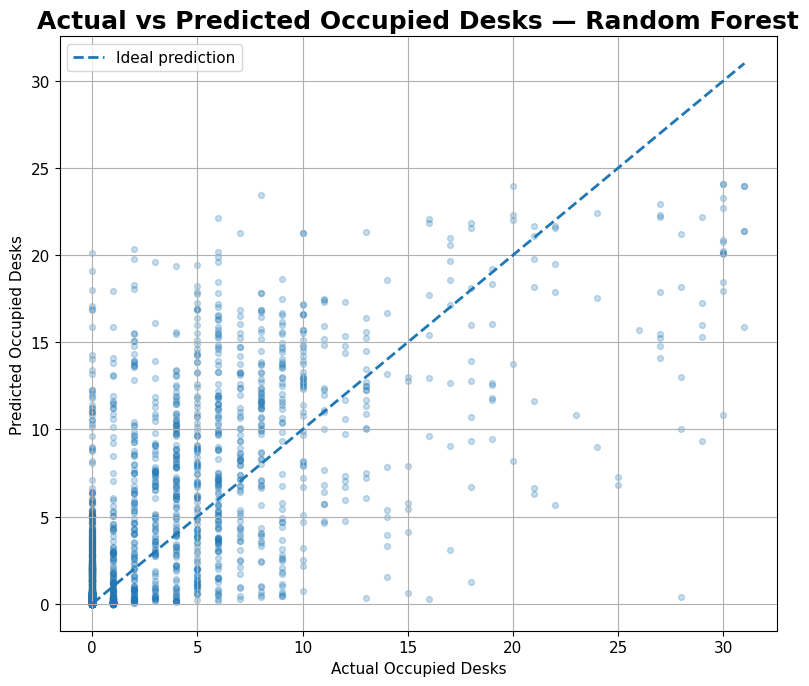

In [12]:
# ACTUAL VS PREDICTED OCCUPANCY — ROOM 4.9


fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    y_test,
    rf_predictions,
    alpha=0.25,
    s=18
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

ax.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2,
    label="Ideal prediction"
)

ax.set_title(
    "Actual vs Predicted Occupied Desks — Random Forest",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Actual Occupied Desks")
ax.set_ylabel("Predicted Occupied Desks")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_1_Actual_vs_Predicted_Occupied_Desks.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

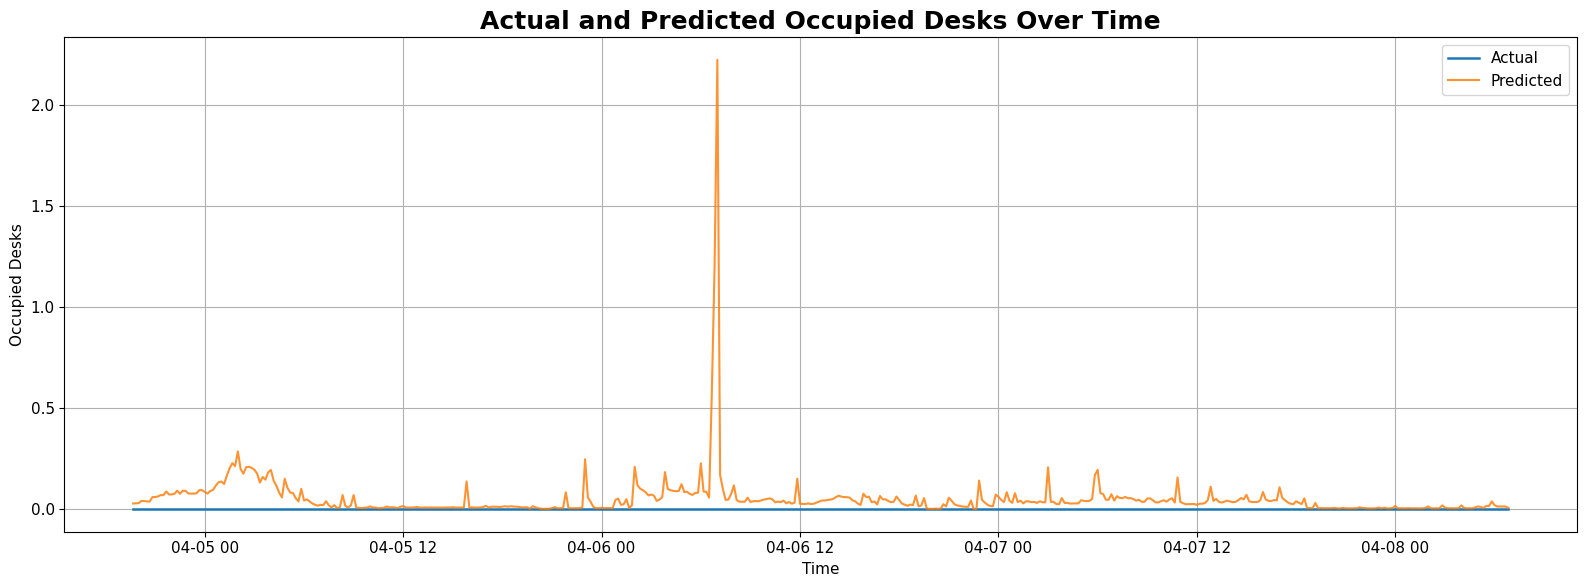

In [13]:
# TIME SERIES COMPARISON — ROOM 4.9


comparison_size = 500

comparison_df = (
    test_df
    .iloc[:comparison_size]
    .copy()
)

comparison_df["predicted_occupied_desks"] = (
    rf_predictions[:comparison_size]
)

fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.plot(
    comparison_df["ts"],
    comparison_df["occupied_desks"],
    label="Actual",
    linewidth=1.8
)

ax.plot(
    comparison_df["ts"],
    comparison_df["predicted_occupied_desks"],
    label="Predicted",
    linewidth=1.5,
    alpha=0.85
)

ax.set_title(
    "Actual and Predicted Occupied Desks Over Time",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Occupied Desks")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_2_Actual_vs_Predicted_TimeSeries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Feature,Importance
9,pir_any,0.2500
0,co2_avg,0.1359
2,co2_lag_1,0.0958
1,co2_change_10min,0.0826
6,temperature_avg,0.0819
5,co2_rolling_mean_30min,0.0584
3,co2_lag_2,0.0523
4,co2_lag_3,0.0517
11,hour_sin,0.0411
7,humidity_avg,0.0403


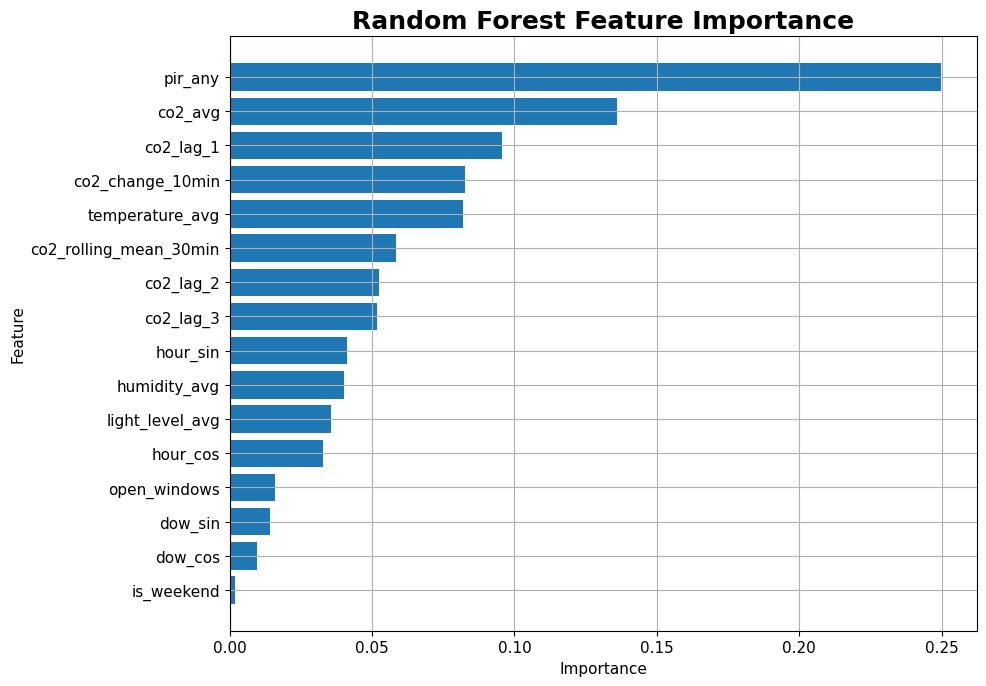

In [14]:
# RANDOM FOREST FEATURE IMPORTANCE — ROOM 4.9


feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.round(4)
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()

fig.savefig(
    "Figure_ML_3_Random_Forest_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Two-Stage Occupancy Estimation

Because the occupancy target is strongly imbalanced toward empty-room observations, an additional two-stage modelling approach is evaluated.

The first stage classifies each observation as empty or occupied. The second stage estimates the occupancy level only for observations classified as occupied. The final predictions combine the outputs of both stages.

In [15]:
# TWO-STAGE MODEL — STAGE 1: OCCUPANCY CLASSIFICATION


y_train_binary = (
    y_train > 0
).astype(int)

y_test_binary = (
    y_test > 0
).astype(int)

classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

classifier.fit(
    X_train,
    y_train_binary
)

class_predictions = classifier.predict(
    X_test
)

classification_results = pd.DataFrame([{
    "Accuracy": accuracy_score(
        y_test_binary,
        class_predictions
    ),
    "Precision": precision_score(
        y_test_binary,
        class_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_binary,
        class_predictions,
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test_binary,
        class_predictions,
        zero_division=0
    )
}])

display(
    classification_results.round(3)
)

print("\nClassification report:")
print(
    classification_report(
        y_test_binary,
        class_predictions,
        target_names=["Empty", "Occupied"],
        zero_division=0
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test_binary,
        class_predictions
    )
)

,Accuracy,Precision,Recall,F1-score
0,0.93,0.84,0.699,0.763



Classification report:
              precision    recall  f1-score   support

       Empty       0.94      0.97      0.96      6488
    Occupied       0.84      0.70      0.76      1250

    accuracy                           0.93      7738
   macro avg       0.89      0.84      0.86      7738
weighted avg       0.93      0.93      0.93      7738


Confusion matrix:
[[6321  167]
 [ 376  874]]


In [16]:
# TWO-STAGE MODEL — STAGE 2: OCCUPANCY REGRESSION


occupied_train_mask = y_train > 0

X_train_occupied = X_train.loc[
    occupied_train_mask
]

y_train_occupied = y_train.loc[
    occupied_train_mask
]

occupied_regressor = RandomForestRegressor(
    n_estimators=400,
    max_depth=16,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

occupied_regressor.fit(
    X_train_occupied,
    y_train_occupied
)

print(
    "Occupied training observations:",
    len(y_train_occupied)
)

print(
    "Mean occupied desks in occupied training periods:",
    round(y_train_occupied.mean(), 2)
)

Occupied training observations: 5054
Mean occupied desks in occupied training periods: 8.76


In [17]:
# TWO-STAGE MODEL — COMBINED PREDICTIONS

two_stage_predictions = np.zeros(
    len(X_test)
)

predicted_occupied_mask = (
    class_predictions == 1
)

two_stage_predictions[predicted_occupied_mask] = (
    occupied_regressor.predict(
        X_test.loc[predicted_occupied_mask]
    )
)

two_stage_predictions = np.clip(
    two_stage_predictions,
    0,
    32
)

two_stage_results = evaluate_regression_model(
    "Two-Stage Random Forest",
    y_test,
    two_stage_predictions
)

comparison_results = pd.DataFrame([
    baseline_results,
    linear_results,
    rf_results,
    two_stage_results
]).round(3)

display(comparison_results)

,Model,MAE,RMSE,R²
0,Median Baseline,0.963,3.410,-0.087
1,Linear Regression,1.240,2.988,0.166
2,Random Forest,0.853,2.420,0.452
3,Two-Stage Random Forest,0.855,2.655,0.341


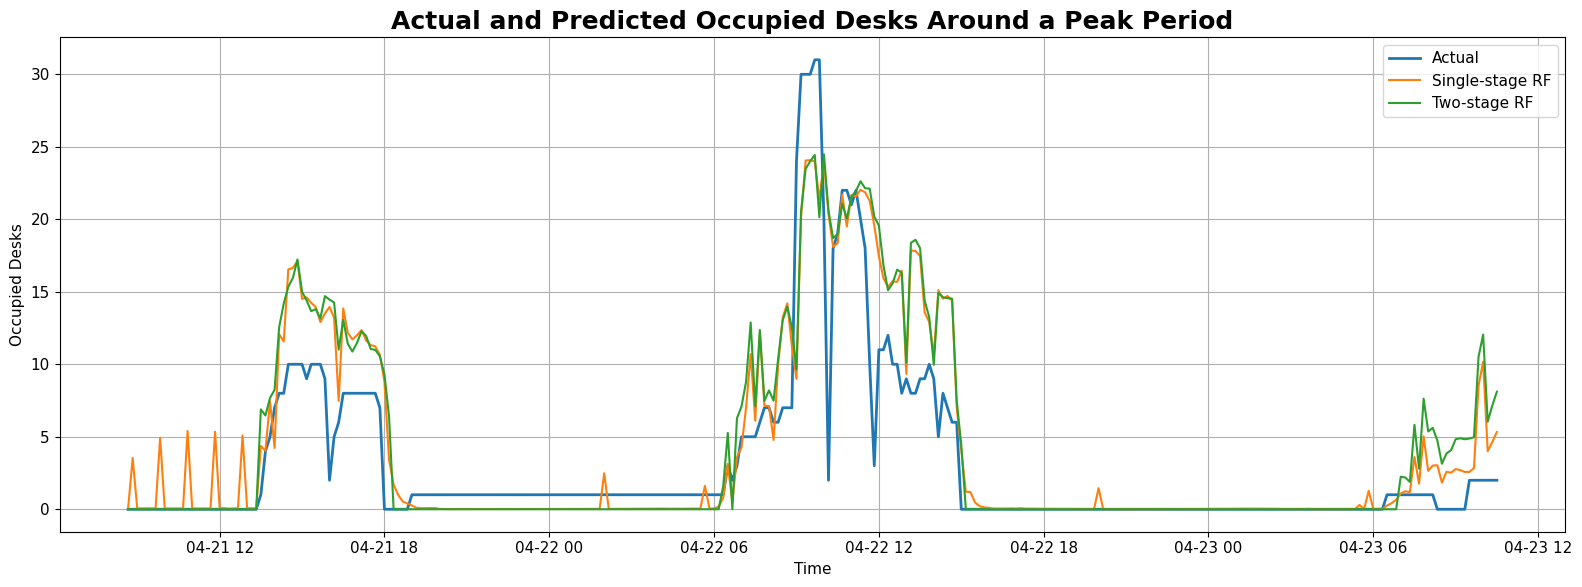

In [18]:
# REPRESENTATIVE PEAK TIME WINDOW — ROOM 4.9


peak_position = np.argmax(
    y_test.to_numpy()
)

window_start = max(
    0,
    peak_position - 150
)

window_end = min(
    len(test_df),
    peak_position + 150
)

comparison_df = test_df.iloc[
    window_start:window_end
].copy()

comparison_df["single_stage_prediction"] = (
    rf_predictions[
        window_start:window_end
    ]
)

comparison_df["two_stage_prediction"] = (
    two_stage_predictions[
        window_start:window_end
    ]
)

fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.plot(
    comparison_df["ts"],
    comparison_df["occupied_desks"],
    label="Actual",
    linewidth=2
)

ax.plot(
    comparison_df["ts"],
    comparison_df["single_stage_prediction"],
    label="Single-stage RF",
    linewidth=1.5
)

ax.plot(
    comparison_df["ts"],
    comparison_df["two_stage_prediction"],
    label="Two-stage RF",
    linewidth=1.5
)

ax.set_title(
    "Actual and Predicted Occupied Desks Around a Peak Period",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Occupied Desks")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_4_Two_Stage_Peak_Period.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# HISTOGRAM GRADIENT BOOSTING REGRESSOR — ROOM 4.9


hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_depth=8,
    max_iter=400,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

hgb.fit(
    X_train,
    y_train
)

hgb_pred = hgb.predict(
    X_test
)

print(
    "MAE :",
    round(
        mean_absolute_error(y_test, hgb_pred),
        3
    )
)

print(
    "RMSE:",
    round(
        np.sqrt(
            mean_squared_error(y_test, hgb_pred)
        ),
        3
    )
)

print(
    "R²  :",
    round(
        r2_score(y_test, hgb_pred),
        3
    )
)

MAE : 0.913
RMSE: 2.574
R²  : 0.381


In [20]:
# FINAL MODEL COMPARISON — ROOM 4.9 OCCUPANCY ESTIMATION


hgb_results = evaluate_regression_model(
    "HistGradientBoosting",
    y_test,
    hgb_pred
)

display(
    pd.DataFrame([hgb_results]).round(3)
)

occupancy_model_comparison = pd.DataFrame([
    baseline_results,
    linear_results,
    rf_results,
    two_stage_results,
    hgb_results
])

occupancy_model_comparison = (
    occupancy_model_comparison
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(
    occupancy_model_comparison.round(3)
)

occupancy_model_comparison.to_csv(
    "room_4_9_occupancy_model_comparison.csv",
    index=False
)

print(
    "Saved: room_4_9_occupancy_model_comparison.csv"
)

,Model,MAE,RMSE,R²
0,HistGradientBoosting,0.913,2.574,0.381


,Model,MAE,RMSE,R²
0,Random Forest,0.853,2.420,0.452
1,HistGradientBoosting,0.913,2.574,0.381
2,Two-Stage Random Forest,0.855,2.655,0.341
3,Linear Regression,1.240,2.988,0.166
4,Median Baseline,0.963,3.410,-0.087


Saved: room_4_9_occupancy_model_comparison.csv


## 2. Methodology Evaluation in Room 2.3

The occupancy estimation methodology is additionally evaluated in Room 2.3 using an independent reference source.

In this room, the target variable is the number of persons reported by the Workplace Occupancy sensor. The same feature-engineering principles and chronological 80/20 evaluation strategy used for Room 4.9 are applied.

This experiment examines whether similar environmental and temporal information can support occupancy estimation under different room conditions and with a different occupancy reference system.

In [21]:
# ROOM 2.3 — DATA PREPARATION AND FEATURE ENGINEERING


df_23 = pd.read_csv(
    "room_2_3_final.csv"
)

df_23["ts"] = pd.to_datetime(
    df_23["ts"],
    errors="coerce"
)

df_23 = (
    df_23
    .dropna(subset=["ts"])
    .sort_values("ts")
    .drop_duplicates(subset=["ts"])
    .reset_index(drop=True)
)

# Temporal features
df_23["hour"] = df_23["ts"].dt.hour
df_23["day_of_week"] = df_23["ts"].dt.dayofweek

df_23["is_weekend"] = (
    df_23["day_of_week"] >= 5
).astype(int)

# Cyclical representation of hour
df_23["hour_sin"] = np.sin(
    2 * np.pi * df_23["hour"] / 24
)

df_23["hour_cos"] = np.cos(
    2 * np.pi * df_23["hour"] / 24
)

# Cyclical representation of day of week
df_23["dow_sin"] = np.sin(
    2 * np.pi * df_23["day_of_week"] / 7
)

df_23["dow_cos"] = np.cos(
    2 * np.pi * df_23["day_of_week"] / 7
)

# CO₂-derived temporal features
df_23["co2_change_10min"] = (
    df_23["co2"].diff()
)

df_23["co2_lag_1"] = (
    df_23["co2"].shift(1)
)

df_23["co2_lag_2"] = (
    df_23["co2"].shift(2)
)

df_23["co2_lag_3"] = (
    df_23["co2"].shift(3)
)

# Rolling mean of the previous 30 minutes
df_23["co2_rolling_mean_30min"] = (
    df_23["co2"]
    .shift(1)
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

print(
    "Room 2.3 feature engineering completed successfully."
)
print()
print("Rows:", len(df_23))

print(
    "Time range:",
    df_23["ts"].min(),
    "→",
    df_23["ts"].max()
)

display(df_23.head())

Room 2.3 feature engineering completed successfully.

Rows: 38645
Time range: 2025-09-01 14:40:00 → 2026-05-27 23:20:00


,ts,co2,temperature,humidity,light_level,pir,people_count_all,people_count_max,region_count,open_windows_all,hour,day_of_week,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,co2_change_10min,co2_lag_1,co2_lag_2,co2_lag_3,co2_rolling_mean_30min
0,2025-09-01 14:40:00,544.0,29.9,37.5,1.0,0,0,2,0,1,14,0,0,-0.500000,-0.866025,0.0,1.0,NaN,NaN,NaN,NaN,NaN
1,2025-09-01 14:50:00,544.0,29.9,37.5,1.0,1,0,2,0,1,14,0,0,-0.500000,-0.866025,0.0,1.0,0.0,544.0,NaN,NaN,544.000000
2,2025-09-01 15:00:00,543.0,29.9,37.5,1.0,0,0,2,0,1,15,0,0,-0.707107,-0.707107,0.0,1.0,-1.0,544.0,544.0,NaN,544.000000
3,2025-09-01 15:10:00,543.0,29.9,37.5,1.0,0,0,2,0,1,15,0,0,-0.707107,-0.707107,0.0,1.0,0.0,543.0,544.0,544.0,543.666667
4,2025-09-01 15:20:00,544.0,29.9,37.5,1.0,0,0,2,0,1,15,0,0,-0.707107,-0.707107,0.0,1.0,1.0,543.0,543.0,544.0,543.333333


In [22]:
# ROOM 2.3 — MODEL DATASET


feature_columns_23 = [
    "co2",
    "co2_change_10min",
    "co2_lag_1",
    "co2_lag_2",
    "co2_lag_3",
    "co2_rolling_mean_30min",
    "temperature",
    "humidity",
    "light_level",
    "pir",
    "open_windows_all",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "is_weekend"
]

target_column_23 = "people_count_all"

model_df_23 = (
    df_23[
        ["ts"]
        + feature_columns_23
        + [target_column_23]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
    .copy()
)

# Remove only physically invalid negative target values
model_df_23 = (
    model_df_23[
        model_df_23[target_column_23] >= 0
    ]
    .reset_index(drop=True)
)

print("Room 2.3 model dataset created successfully.")
print()
print("Rows:", model_df_23.shape[0])
print("Columns:", model_df_23.shape[1])

print("\nTarget distribution:")
display(
    model_df_23[target_column_23]
    .describe()
    .round(3)
    .to_frame("people_count_all")
)

occupied_percentage_23 = (
    100
    * (model_df_23[target_column_23] > 0).mean()
)

print(
    "Occupied observations:",
    (model_df_23[target_column_23] > 0).sum()
)

print(
    "Occupied percentage:",
    round(occupied_percentage_23, 2),
    "%"
)

display(model_df_23.head())

Room 2.3 model dataset created successfully.

Rows: 38642
Columns: 18

Target distribution:


,people_count_all
count,38642.000
mean,0.763
std,3.237
min,0.000
25%,0.000
50%,0.000
75%,0.000
max,40.000


Occupied observations: 4745
Occupied percentage: 12.28 %


,ts,co2,co2_change_10min,co2_lag_1,co2_lag_2,co2_lag_3,co2_rolling_mean_30min,temperature,humidity,light_level,pir,open_windows_all,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,people_count_all
0,2025-09-01 15:10:00,543.0,0.0,543.0,544.0,544.0,543.666667,29.9,37.5,1.0,0,1,-0.707107,-0.707107,0.0,1.0,0,0
1,2025-09-01 15:20:00,544.0,1.0,543.0,543.0,544.0,543.333333,29.9,37.5,1.0,0,1,-0.707107,-0.707107,0.0,1.0,0,0
2,2025-09-01 15:30:00,544.0,0.0,544.0,543.0,543.0,543.333333,29.9,37.5,1.0,0,1,-0.707107,-0.707107,0.0,1.0,0,0
3,2025-09-01 15:40:00,545.0,1.0,544.0,544.0,543.0,543.666667,29.9,38.0,1.0,0,1,-0.707107,-0.707107,0.0,1.0,0,0
4,2025-09-01 15:50:00,545.0,0.0,545.0,544.0,544.0,544.333333,29.8,38.0,1.0,0,1,-0.707107,-0.707107,0.0,1.0,0,0


,Observations
people_count_all,
0,33897
1,1931
2,387
3,250
4,215
5,220
6,149
7,157
8,132


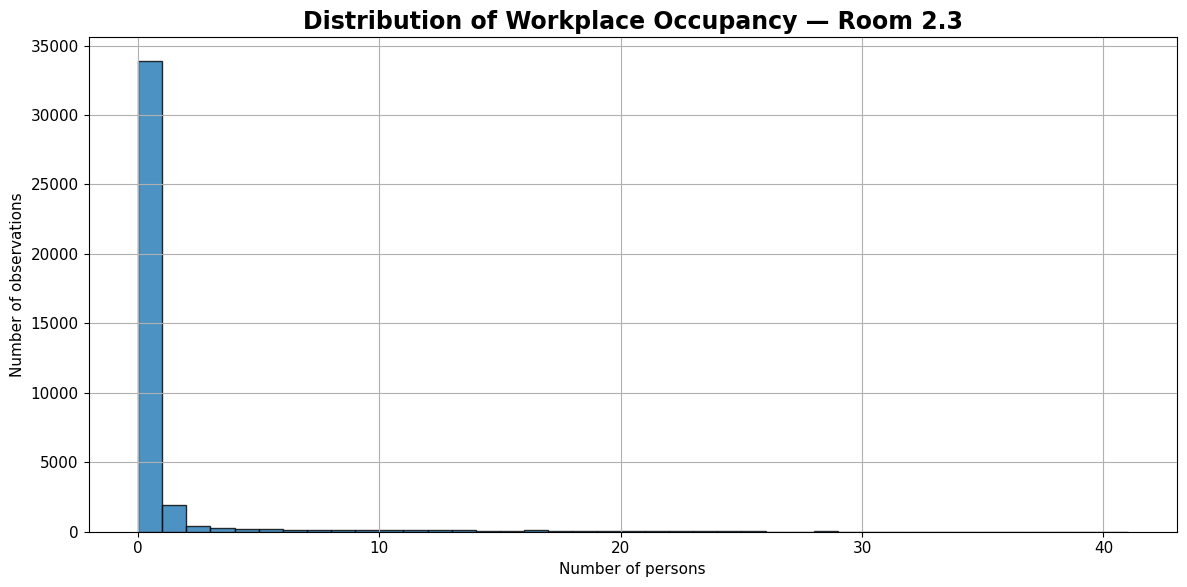

In [23]:
# ROOM 2.3 — TARGET DISTRIBUTION

target_counts_23 = (
    model_df_23[target_column_23]
    .value_counts()
    .sort_index()
)

display(
    target_counts_23
    .rename("Observations")
    .to_frame()
    .head(25)
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

ax.hist(
    model_df_23[target_column_23],
    bins=range(
        0,
        int(model_df_23[target_column_23].max()) + 2
    ),
    edgecolor="black",
    alpha=0.8
)

ax.set_title(
    "Distribution of Workplace Occupancy — Room 2.3",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Number of persons")
ax.set_ylabel("Number of observations")

fig.tight_layout()

fig.savefig(
    "Figure_ML_7_Room_2_3_Occupancy_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
# ROOM 2.3 — CHRONOLOGICAL TRAIN / TEST SPLIT


split_index_23 = int(
    len(model_df_23) * 0.80
)

train_df_23 = (
    model_df_23
    .iloc[:split_index_23]
    .copy()
)

test_df_23 = (
    model_df_23
    .iloc[split_index_23:]
    .copy()
)

X_train_23 = train_df_23[
    feature_columns_23
]

y_train_23 = train_df_23[
    target_column_23
]

X_test_23 = test_df_23[
    feature_columns_23
]

y_test_23 = test_df_23[
    target_column_23
]

print("Room 2.3 chronological split completed.")
print()

print("Training rows:", len(train_df_23))
print("Testing rows :", len(test_df_23))

print("\nTraining period:")
print(
    train_df_23["ts"].min(),
    "→",
    train_df_23["ts"].max()
)

print("\nTesting period:")
print(
    test_df_23["ts"].min(),
    "→",
    test_df_23["ts"].max()
)

print("\nMean people count:")
print(
    "Train:",
    round(y_train_23.mean(), 3)
)

print(
    "Test :",
    round(y_test_23.mean(), 3)
)

print("\nOccupied observations:")

print(
    "Train:",
    int((y_train_23 > 0).sum()),
    f"({100 * (y_train_23 > 0).mean():.2f}%)"
)

print(
    "Test :",
    int((y_test_23 > 0).sum()),
    f"({100 * (y_test_23 > 0).mean():.2f}%)"
)

Room 2.3 chronological split completed.

Training rows: 30913
Testing rows : 7729

Training period:
2025-09-01 15:10:00 → 2026-04-04 07:10:00

Testing period:
2026-04-04 07:20:00 → 2026-05-27 23:20:00

Mean people count:
Train: 0.826
Test : 0.51

Occupied observations:
Train: 3904 (12.63%)
Test : 841 (10.88%)


### Occupancy Model Evaluation

The same main modelling approaches are evaluated in Room 2.3. Particular attention is again given to performance during actual occupied periods, since the target distribution is dominated by observations corresponding to an empty room.

Random Forest performance is also examined through feature importance and comparison with the two-stage occupancy estimation approach.

In [25]:
# ROOM 2.3 — BASELINE, LINEAR REGRESSION AND RANDOM FOREST



# Median Baseline


baseline_model_23 = DummyRegressor(
    strategy="median"
)

baseline_model_23.fit(
    X_train_23,
    y_train_23
)

baseline_predictions_23 = (
    baseline_model_23.predict(
        X_test_23
    )
)

baseline_results_23 = evaluate_regression_model(
    "Median Baseline — Room 2.3",
    y_test_23,
    baseline_predictions_23
)


# Linear Regression


linear_pipeline_23 = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_pipeline_23.fit(
    X_train_23,
    y_train_23
)

linear_predictions_23 = (
    linear_pipeline_23.predict(
        X_test_23
    )
)

linear_predictions_23 = np.clip(
    linear_predictions_23,
    0,
    None
)

linear_results_23 = evaluate_regression_model(
    "Linear Regression — Room 2.3",
    y_test_23,
    linear_predictions_23
)

# Random Forest


rf_model_23 = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_model_23.fit(
    X_train_23,
    y_train_23
)

rf_predictions_23 = (
    rf_model_23.predict(
        X_test_23
    )
)

rf_predictions_23 = np.clip(
    rf_predictions_23,
    0,
    None
)

rf_results_23 = evaluate_regression_model(
    "Random Forest — Room 2.3",
    y_test_23,
    rf_predictions_23
)

results_23 = pd.DataFrame([
    baseline_results_23,
    linear_results_23,
    rf_results_23
]).round(3)

display(results_23)

,Model,MAE,RMSE,R²
0,Median Baseline — Room 2.3,0.510,2.201,-0.057
1,Linear Regression — Room 2.3,0.613,1.590,0.448
2,Random Forest — Room 2.3,0.431,1.535,0.486


In [26]:
# ROOM 2.3 — PERFORMANCE DURING OCCUPIED PERIODS

occupied_test_mask_23 = (
    y_test_23 > 0
)

occupied_test_count_23 = (
    occupied_test_mask_23.sum()
)

print(
    "Occupied test observations:",
    occupied_test_count_23
)

print(
    "Percentage of occupied test observations:",
    round(
        100 * occupied_test_mask_23.mean(),
        2
    ),
    "%"
)

if occupied_test_count_23 > 0:

    occupied_results_23 = evaluate_regression_model(
        "Random Forest — Occupied Periods — Room 2.3",
        y_test_23.loc[occupied_test_mask_23],
        rf_predictions_23[occupied_test_mask_23]
    )

    display(
        pd.DataFrame([
            occupied_results_23
        ]).round(3)
    )

else:
    occupied_results_23 = None

    print(
        "No occupied observations exist in the chronological "
        "test set. Occupied-period regression metrics cannot "
        "be calculated."
    )

Occupied test observations: 841
Percentage of occupied test observations: 10.88 %


,Model,MAE,RMSE,R²
0,Random Forest — Occupied Periods — Room 2.3,2.667,3.984,0.295


In [27]:
# ROOM 2.3 — ERROR BY OCCUPANCY STATE


evaluation_df_23 = pd.DataFrame({
    "Actual": y_test_23.to_numpy(),
    "Predicted": rf_predictions_23
})

evaluation_df_23["Occupancy State"] = np.where(
    evaluation_df_23["Actual"] > 0,
    "Occupied",
    "Empty"
)

state_rows_23 = []

for state_name_23, group_23 in (
    evaluation_df_23.groupby("Occupancy State")
):
    state_rows_23.append({
        "Occupancy State": state_name_23,
        "Observations": len(group_23),
        "Actual Mean": group_23["Actual"].mean(),
        "Predicted Mean": group_23["Predicted"].mean(),
        "MAE": mean_absolute_error(
            group_23["Actual"],
            group_23["Predicted"]
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                group_23["Actual"],
                group_23["Predicted"]
            )
        )
    })

state_results_23 = pd.DataFrame(
    state_rows_23
)

display(
    state_results_23.round(3)
)

,Occupancy State,Observations,Actual Mean,Predicted Mean,MAE,RMSE
0,Empty,6888,0.000,0.157,0.157,0.840
1,Occupied,841,4.688,3.805,2.667,3.984


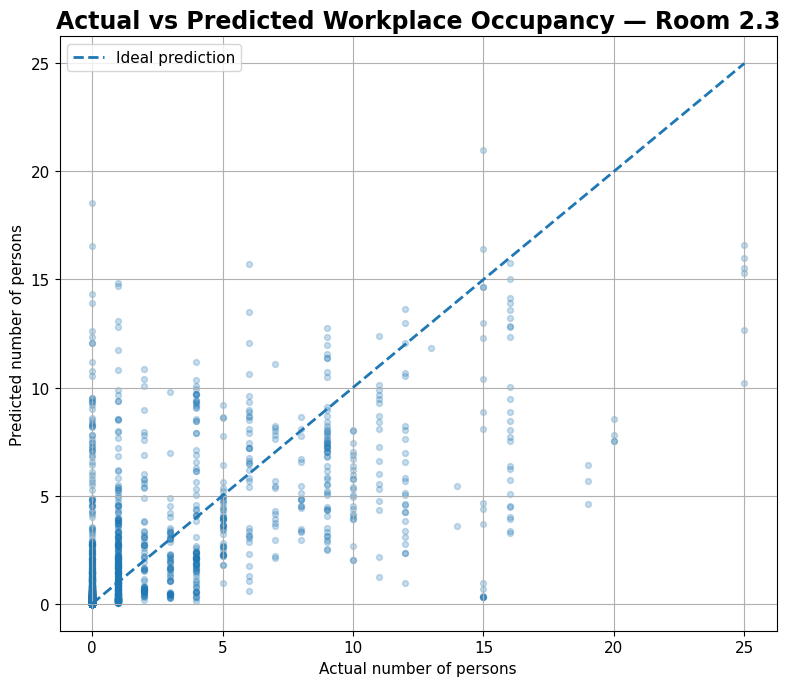

In [28]:
# ROOM 2.3 — ACTUAL VS PREDICTED


fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.scatter(
    y_test_23,
    rf_predictions_23,
    alpha=0.25,
    s=18
)

maximum_value_23 = max(
    float(y_test_23.max()),
    float(rf_predictions_23.max()),
    1
)

ax.plot(
    [0, maximum_value_23],
    [0, maximum_value_23],
    linestyle="--",
    linewidth=2,
    label="Ideal prediction"
)

ax.set_title(
    "Actual vs Predicted Workplace Occupancy — Room 2.3",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Actual number of persons")
ax.set_ylabel("Predicted number of persons")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_8_Room_2_3_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Feature,Importance
0,co2,0.2085
1,co2_lag_1,0.1656
2,co2_rolling_mean_30min,0.1029
3,co2_lag_2,0.1011
4,co2_lag_3,0.0801
5,co2_change_10min,0.0629
6,temperature,0.0589
7,open_windows_all,0.0398
8,pir,0.0370
9,humidity,0.0303


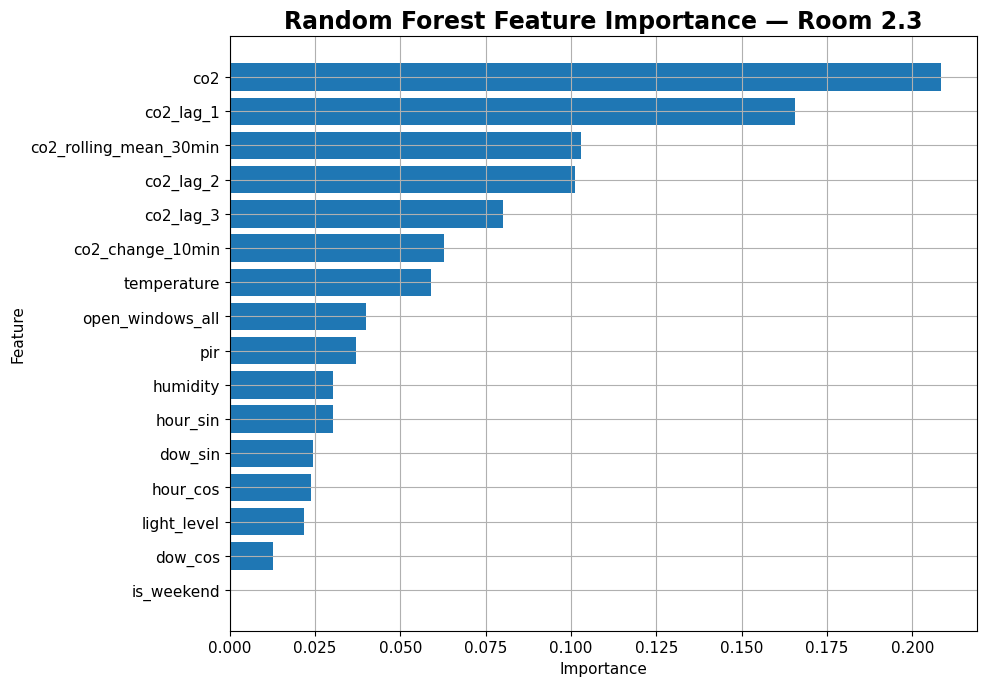

In [29]:
# ROOM 2.3 — RANDOM FOREST FEATURE IMPORTANCE


feature_importance_23 = pd.DataFrame({
    "Feature": feature_columns_23,
    "Importance": rf_model_23.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_23.round(4)
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    feature_importance_23["Feature"][::-1],
    feature_importance_23["Importance"][::-1]
)

ax.set_title(
    "Random Forest Feature Importance — Room 2.3",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

fig.tight_layout()

fig.savefig(
    "Figure_ML_9_Room_2_3_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# ROOM 2.3 — TWO-STAGE MODEL
# STAGE 1: EMPTY / OCCUPIED CLASSIFICATION


y_train_binary_23 = (
    y_train_23 > 0
).astype(int)

y_test_binary_23 = (
    y_test_23 > 0
).astype(int)

classifier_23 = RandomForestClassifier(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

classifier_23.fit(
    X_train_23,
    y_train_binary_23
)

class_predictions_23 = classifier_23.predict(
    X_test_23
)

classification_results_23 = pd.DataFrame([{
    "Model": "Occupancy Classifier — Room 2.3",
    "Accuracy": accuracy_score(
        y_test_binary_23,
        class_predictions_23
    ),
    "Precision": precision_score(
        y_test_binary_23,
        class_predictions_23,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_binary_23,
        class_predictions_23,
        zero_division=0
    ),
    "F1-score": f1_score(
        y_test_binary_23,
        class_predictions_23,
        zero_division=0
    )
}])

display(
    classification_results_23.round(3)
)

print("\nClassification report:")
print(
    classification_report(
        y_test_binary_23,
        class_predictions_23,
        labels=[0, 1],
        target_names=["Empty", "Occupied"],
        zero_division=0
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test_binary_23,
        class_predictions_23,
        labels=[0, 1]
    )
)

,Model,Accuracy,Precision,Recall,F1-score
0,Occupancy Classifier — Room 2.3,0.93,0.636,0.835,0.722



Classification report:
              precision    recall  f1-score   support

       Empty       0.98      0.94      0.96      6888
    Occupied       0.64      0.83      0.72       841

    accuracy                           0.93      7729
   macro avg       0.81      0.89      0.84      7729
weighted avg       0.94      0.93      0.93      7729


Confusion matrix:
[[6487  401]
 [ 139  702]]


In [31]:
# ROOM 2.3 — STAGE 2 REGRESSION AND FINAL COMBINATION


occupied_train_mask_23 = (
    y_train_23 > 0
)

X_train_occupied_23 = (
    X_train_23.loc[
        occupied_train_mask_23
    ]
)

y_train_occupied_23 = (
    y_train_23.loc[
        occupied_train_mask_23
    ]
)

print(
    "Occupied training observations:",
    len(y_train_occupied_23)
)

if len(y_train_occupied_23) >= 20:

    occupied_regressor_23 = RandomForestRegressor(
        n_estimators=400,
        max_depth=16,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    occupied_regressor_23.fit(
        X_train_occupied_23,
        y_train_occupied_23
    )

    two_stage_predictions_23 = np.zeros(
        len(X_test_23)
    )

    predicted_occupied_mask_23 = (
        class_predictions_23 == 1
    )

    if predicted_occupied_mask_23.sum() > 0:

        two_stage_predictions_23[
            predicted_occupied_mask_23
        ] = occupied_regressor_23.predict(
            X_test_23.loc[
                predicted_occupied_mask_23
            ]
        )

    two_stage_predictions_23 = np.clip(
        two_stage_predictions_23,
        0,
        None
    )

    two_stage_results_23 = evaluate_regression_model(
        "Two-Stage Random Forest — Room 2.3",
        y_test_23,
        two_stage_predictions_23
    )

    comparison_results_23 = pd.DataFrame([
        baseline_results_23,
        linear_results_23,
        rf_results_23,
        two_stage_results_23
    ]).round(3)

    display(
        comparison_results_23
    )

else:

    occupied_regressor_23 = None
    two_stage_predictions_23 = None
    two_stage_results_23 = None

    comparison_results_23 = results_23.copy()

    print(
        "There are not enough occupied training observations "
        "to train the second-stage regressor reliably."
    )

Occupied training observations: 3904


,Model,MAE,RMSE,R²
0,Median Baseline — Room 2.3,0.510,2.201,-0.057
1,Linear Regression — Room 2.3,0.613,1.590,0.448
2,Random Forest — Room 2.3,0.431,1.535,0.486
3,Two-Stage Random Forest — Room 2.3,0.491,1.751,0.331


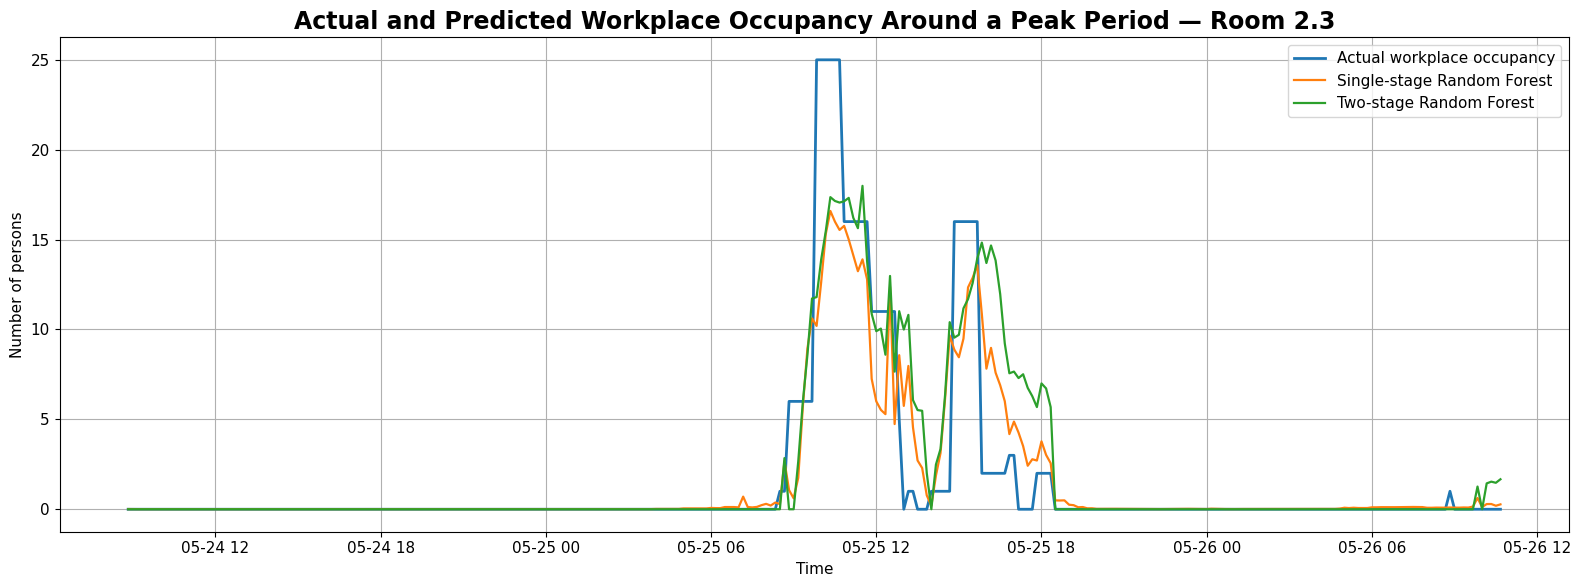

In [32]:
# ROOM 2.3 — REPRESENTATIVE PEAK PERIOD


peak_position_23 = int(
    np.argmax(
        y_test_23.to_numpy()
    )
)

window_start_23 = max(
    0,
    peak_position_23 - 150
)

window_end_23 = min(
    len(test_df_23),
    peak_position_23 + 150
)

peak_comparison_23 = (
    test_df_23
    .iloc[
        window_start_23:window_end_23
    ]
    .copy()
)

peak_comparison_23[
    "single_stage_prediction"
] = (
    rf_predictions_23[
        window_start_23:window_end_23
    ]
)

if two_stage_predictions_23 is not None:
    peak_comparison_23[
        "two_stage_prediction"
    ] = (
        two_stage_predictions_23[
            window_start_23:window_end_23
        ]
    )

fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.plot(
    peak_comparison_23["ts"],
    peak_comparison_23[target_column_23],
    label="Actual workplace occupancy",
    linewidth=2
)

ax.plot(
    peak_comparison_23["ts"],
    peak_comparison_23[
        "single_stage_prediction"
    ],
    label="Single-stage Random Forest",
    linewidth=1.6
)

if two_stage_predictions_23 is not None:
    ax.plot(
        peak_comparison_23["ts"],
        peak_comparison_23[
            "two_stage_prediction"
        ],
        label="Two-stage Random Forest",
        linewidth=1.6
    )

ax.set_title(
    "Actual and Predicted Workplace Occupancy "
    "Around a Peak Period — Room 2.3",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Number of persons")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_10_Room_2_3_Peak_Period.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# ROOM 2.3 — SAVE PREDICTIONS AND RESULTS


room23_predictions_df = test_df_23[
    [
        "ts",
        target_column_23,
        "co2",
        "temperature",
        "humidity",
        "light_level",
        "pir",
        "open_windows_all"
    ]
].copy()

room23_predictions_df[
    "predicted_people_rf"
] = rf_predictions_23

if two_stage_predictions_23 is not None:
    room23_predictions_df[
        "predicted_people_two_stage"
    ] = two_stage_predictions_23

room23_predictions_df[
    "absolute_error_rf"
] = (
    room23_predictions_df[target_column_23]
    - room23_predictions_df[
        "predicted_people_rf"
    ]
).abs()

room23_predictions_df.to_csv(
    "room_2_3_occupancy_validation_predictions.csv",
    index=False
)

comparison_results_23.to_csv(
    "room_2_3_occupancy_validation_metrics.csv",
    index=False
)

feature_importance_23.to_csv(
    "room_2_3_feature_importance.csv",
    index=False
)


print("=" * 70)
print("ROOM 2.3 VALIDATION EXPERIMENT COMPLETED")
print("=" * 70)

print(
    "Saved: room_2_3_occupancy_validation_predictions.csv"
)

print(
    "Saved: room_2_3_occupancy_validation_metrics.csv"
)

print(
    "Saved: room_2_3_feature_importance.csv"
)


ROOM 2.3 VALIDATION EXPERIMENT COMPLETED
Saved: room_2_3_occupancy_validation_predictions.csv
Saved: room_2_3_occupancy_validation_metrics.csv
Saved: room_2_3_feature_importance.csv


## 3. Cross-Room Methodology Validation

The results from Rooms 4.9 and 2.3 provide two independent evaluations of the occupancy estimation methodology using different reference occupancy measurements.

The comparison is used to assess whether the same general modelling framework can extract useful occupancy-related information from environmental and temporal measurements across different indoor environments.

In [34]:
# METHODOLOGY VALIDATION SUMMARY — ROOMS 4.9 AND 2.3


methodology_validation_summary = pd.DataFrame([
    {
        "Room": "4.9",
        "Reference target": "Occupied desks",
        "Training observations": len(X_train),
        "Testing observations": len(X_test),
        "Occupied test percentage": (
            100 * (y_test > 0).mean()
        ),
        "Random Forest MAE": rf_results["MAE"],
        "Random Forest RMSE": rf_results["RMSE"],
        "Random Forest R²": rf_results["R²"]
    },
    {
        "Room": "2.3",
        "Reference target": "Workplace people count",
        "Training observations": len(X_train_23),
        "Testing observations": len(X_test_23),
        "Occupied test percentage": (
            100 * (y_test_23 > 0).mean()
        ),
        "Random Forest MAE": rf_results_23["MAE"],
        "Random Forest RMSE": rf_results_23["RMSE"],
        "Random Forest R²": rf_results_23["R²"]
    }
])

display(
    methodology_validation_summary.round(3)
)

,Room,Reference target,Training observations,Testing observations,Occupied test percentage,Random Forest MAE,Random Forest RMSE,Random Forest R²
0,4.9,Occupied desks,30951,7738,16.154,0.853,2.420,0.452
1,2.3,Workplace people count,30913,7729,10.881,0.431,1.535,0.486


## 4. People Counter Assessment and Correction in Room 3.9

Room 3.9 does not provide an independent continuous occupancy reference equivalent to the Desk Occupancy system of Room 4.9 or the Workplace Occupancy measurement of Room 2.3.

The occupancy estimation model is therefore applied as an environmental supporting signal for assessing the consistency of the People Counter measurements.

The objective is not to treat the Machine Learning prediction as ground truth, but to identify observations where the raw People Counter estimate exhibits physically implausible or strongly inconsistent behaviour.

In [35]:
# CROSS-ROOM APPLICATION — ROOM 3.9


df_39 = pd.read_csv(
    "room_3_9_final.csv"
)

df_39["ts"] = pd.to_datetime(
    df_39["ts"],
    errors="coerce"
)

df_39 = (
    df_39
    .dropna(subset=["ts"])
    .sort_values("ts")
    .reset_index(drop=True)
)

print("Room 3.9 dataset loaded successfully.")
print()
print("Rows:", df_39.shape[0])
print("Columns:", df_39.shape[1])
print(
    "Time range:",
    df_39["ts"].min(),
    "→",
    df_39["ts"].max()
)

display(df_39.head())

Room 3.9 dataset loaded successfully.

Rows: 38307
Columns: 12
Time range: 2025-08-31 23:40:00 → 2026-05-28 16:50:00


,ts,co2,humidity,light_level,pir,temperature,co2_level,line_1_period_in,line_1_period_out,line_1_total_in,line_1_total_out,open_windows_all
0,2025-08-31 23:40:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
1,2025-08-31 23:50:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
2,2025-09-01 00:00:00,417.0,41.0,0.0,0,29.8,Low,0,0,0,0,0
3,2025-09-01 00:10:00,416.0,41.0,0.0,0,29.9,Low,0,0,0,0,0
4,2025-09-01 00:20:00,416.0,41.0,0.0,0,29.8,Low,0,0,0,0,0


In [36]:
# FEATURE ALIGNMENT — ROOM 3.9


# Align Room 3.9 sensor variables with the Room 4.9 feature schema
df_39["co2_avg"] = df_39["co2"]
df_39["temperature_avg"] = df_39["temperature"]
df_39["humidity_avg"] = df_39["humidity"]
df_39["light_level_avg"] = df_39["light_level"]
df_39["pir_any"] = df_39["pir"]
df_39["open_windows"] = df_39["open_windows_all"]

# Temporal features
df_39["hour"] = df_39["ts"].dt.hour
df_39["day_of_week"] = df_39["ts"].dt.dayofweek


df_39["is_weekend"] = (
    df_39["day_of_week"] >= 5
).astype(int)

# Cyclical representation of hour
df_39["hour_sin"] = np.sin(
    2 * np.pi * df_39["hour"] / 24
)

df_39["hour_cos"] = np.cos(
    2 * np.pi * df_39["hour"] / 24
)

# Cyclical representation of day of week
df_39["dow_sin"] = np.sin(
    2 * np.pi * df_39["day_of_week"] / 7
)

df_39["dow_cos"] = np.cos(
    2 * np.pi * df_39["day_of_week"] / 7
)

# CO₂-derived temporal features
df_39["co2_change_10min"] = (
    df_39["co2_avg"].diff()
)

df_39["co2_lag_1"] = (
    df_39["co2_avg"].shift(1)
)

df_39["co2_lag_2"] = (
    df_39["co2_avg"].shift(2)
)

df_39["co2_lag_3"] = (
    df_39["co2_avg"].shift(3)
)

df_39["co2_rolling_mean_30min"] = (
    df_39["co2_avg"]
    .shift(1)
    .rolling(
        window=3,
        min_periods=1
    )
    .mean()
)

# Create prediction dataset using the exact Room 4.9 feature schema
room39_model_df = (
    df_39[
        ["ts"] + feature_columns
    ]
    .dropna()
    .copy()
)

print("Room 3.9 features aligned successfully.")
print(
    "Rows available for prediction:",
    len(room39_model_df)
)

display(room39_model_df.head())

Room 3.9 features aligned successfully.
Rows available for prediction: 38304


,ts,co2_avg,co2_change_10min,co2_lag_1,co2_lag_2,co2_lag_3,co2_rolling_mean_30min,temperature_avg,humidity_avg,light_level_avg,pir_any,open_windows,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend
3,2025-09-01 00:10:00,416.0,-1.0,417.0,416.0,416.0,416.333333,29.9,41.0,0.0,0,0,0.0,1.0,0.0,1.0,0
4,2025-09-01 00:20:00,416.0,0.0,416.0,417.0,416.0,416.333333,29.8,41.0,0.0,0,0,0.0,1.0,0.0,1.0,0
5,2025-09-01 00:30:00,415.0,-1.0,416.0,416.0,417.0,416.333333,29.8,41.0,0.0,0,0,0.0,1.0,0.0,1.0,0
6,2025-09-01 00:40:00,415.0,0.0,415.0,416.0,416.0,415.666667,29.8,41.0,0.0,0,0,0.0,1.0,0.0,1.0,0
7,2025-09-01 00:50:00,416.0,1.0,415.0,415.0,416.0,415.333333,29.9,41.0,0.0,0,0,0.0,1.0,0.0,1.0,0


In [37]:
# CROSS-ROOM PREDICTION — ROOM 3.9


X_39 = room39_model_df[
    feature_columns
]

room39_predictions = rf_model.predict(
    X_39
)

room39_predictions = np.clip(
    room39_predictions,
    0,
    32
)

room39_model_df[
    "predicted_occupancy_rf"
] = room39_predictions

print(
    "Cross-room predictions completed successfully."
)

display(
    room39_model_df[
        [
            "ts",
            "co2_avg",
            "pir_any",
            "predicted_occupancy_rf"
        ]
    ].head(20)
)

Cross-room predictions completed successfully.


,ts,co2_avg,pir_any,predicted_occupancy_rf
3,2025-09-01 00:10:00,416.0,0,0.001279
4,2025-09-01 00:20:00,416.0,0,0.001279
5,2025-09-01 00:30:00,415.0,0,0.001279
6,2025-09-01 00:40:00,415.0,0,0.001279
7,2025-09-01 00:50:00,416.0,0,0.009288
8,2025-09-01 01:00:00,415.0,0,0.001275
9,2025-09-01 01:10:00,416.0,0,0.009281
10,2025-09-01 01:20:00,415.0,0,0.001275
11,2025-09-01 01:30:00,415.0,0,0.001275
12,2025-09-01 01:40:00,415.0,0,0.001275


### Raw People Counter Occupancy Estimate

The initial People Counter occupancy estimate is calculated from the difference between cumulative entries and exits.

The resulting time series is examined for physically implausible values and temporal inconsistencies before any correction is applied.


In [38]:
# INITIAL PEOPLE COUNTER OCCUPANCY ESTIMATE — ROOM 3.9


df_39["pc_occupancy_raw"] = (
    df_39["line_1_total_in"]
    - df_39["line_1_total_out"]
)

print(
    df_39["pc_occupancy_raw"]
    .describe()
    .round(2)
)

print(
    "\nNegative values:",
    (
        df_39["pc_occupancy_raw"] < 0
    ).sum()
)

print(
    "Values above 40:",
    (
        df_39["pc_occupancy_raw"] > 40
    ).sum()
)

count    38307.00
mean         0.95
std          3.56
min         -3.00
25%          0.00
50%          0.00
75%          0.00
max         44.00
Name: pc_occupancy_raw, dtype: float64

Negative values: 2164
Values above 40: 8


In [39]:
# RF AND PEOPLE COUNTER COMPARISON — ROOM 3.9


comparison_39 = (
    room39_model_df[
        [
            "ts",
            "predicted_occupancy_rf",
            "co2_avg",
            "temperature_avg",
            "humidity_avg",
            "open_windows"
        ]
    ]
    .merge(
        df_39[
            [
                "ts",
                "pc_occupancy_raw"
            ]
        ],
        on="ts",
        how="left"
    )
)

display(
    comparison_39.head()
)

,ts,predicted_occupancy_rf,co2_avg,temperature_avg,humidity_avg,open_windows,pc_occupancy_raw
0,2025-09-01 00:10:00,0.001279,416.0,29.9,41.0,0,0
1,2025-09-01 00:20:00,0.001279,416.0,29.8,41.0,0,0
2,2025-09-01 00:30:00,0.001279,415.0,29.8,41.0,0,0
3,2025-09-01 00:40:00,0.001279,415.0,29.8,41.0,0,0
4,2025-09-01 00:50:00,0.009288,416.0,29.9,41.0,0,0


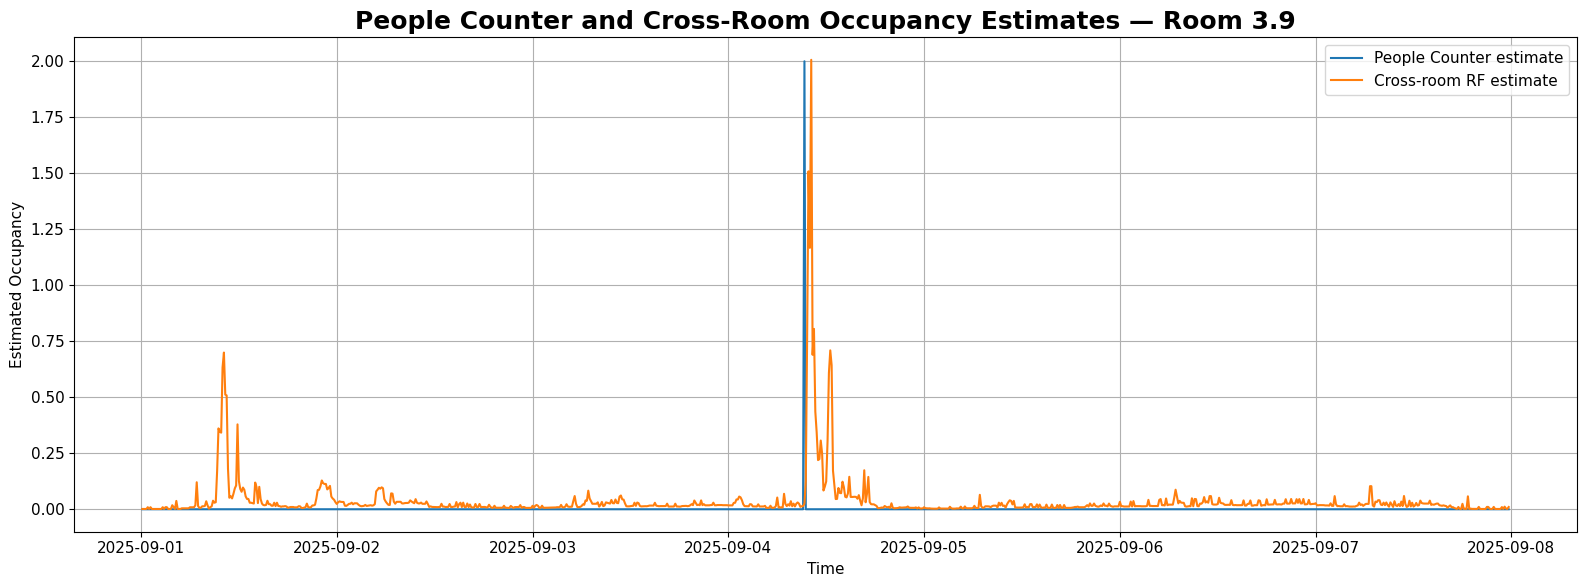

In [40]:
# PEOPLE COUNTER VS CROSS-ROOM RF — ROOM 3.9


sample_39 = comparison_39.iloc[:1000]

fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.plot(
    sample_39["ts"],
    sample_39["pc_occupancy_raw"],
    label="People Counter estimate",
    linewidth=1.5
)

ax.plot(
    sample_39["ts"],
    sample_39["predicted_occupancy_rf"],
    label="Cross-room RF estimate",
    linewidth=1.5
)

ax.set_title(
    "People Counter and Cross-Room Occupancy Estimates — Room 3.9",
    fontsize=18,
    weight="bold"
)

ax.set_xlabel("Time")
ax.set_ylabel("Estimated Occupancy")
ax.legend()

fig.tight_layout()

fig.savefig(
    "Figure_ML_5_Cross_Room_Occupancy_Room_3_9.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
# PEOPLE COUNTER QUALITY ASSESSMENT — ROOM 3.9


print("=" * 60)
print("People Counter Quality Assessment")
print("=" * 60)

print(
    f"Total records: {len(comparison_39):,}"
)

print(
    f"\nMinimum occupancy: "
    f"{comparison_39['pc_occupancy_raw'].min()}"
)

print(
    f"Maximum occupancy: "
    f"{comparison_39['pc_occupancy_raw'].max()}"
)

negative = (
    comparison_39["pc_occupancy_raw"] < 0
).sum()

zero = (
    comparison_39["pc_occupancy_raw"] == 0
).sum()

positive = (
    comparison_39["pc_occupancy_raw"] > 0
).sum()

print(f"\nNegative values : {negative}")
print(f"Zero values     : {zero}")
print(f"Positive values : {positive}")

print(
    f"\nNegative percentage: "
    f"{100 * negative / len(comparison_39):.2f}%"
)

People Counter Quality Assessment
Total records: 38,304

Minimum occupancy: -3
Maximum occupancy: 44

Negative values : 2164
Zero values     : 28844
Positive values : 7296

Negative percentage: 5.65%


In [42]:
# COMPARISON DATASET ENRICHMENT — ROOM 3.9


comparison_39 = (
    comparison_39
    .sort_values("ts")
    .reset_index(drop=True)
)

# CO₂ change over one 10-minute interval
comparison_39["co2_change_10min"] = (
    comparison_39["co2_avg"]
    - comparison_39["co2_avg"].shift(1)
)

# Rounded RF occupancy estimate
comparison_39["predicted_rounded"] = (
    comparison_39["predicted_occupancy_rf"]
    .round()
    .clip(lower=0)
    .astype(int)
)

# Difference between People Counter and RF estimates
comparison_39["difference"] = (
    comparison_39["pc_occupancy_raw"]
    - comparison_39["predicted_occupancy_rf"]
)

comparison_39["abs_difference"] = (
    comparison_39["difference"].abs()
)

# Primary inconsistency indicators
comparison_39["invalid_negative_pc"] = (
    comparison_39["pc_occupancy_raw"] < 0
)

comparison_39["large_disagreement"] = (
    comparison_39["abs_difference"] >= 5
)

display(
    comparison_39[
        [
            "ts",
            "pc_occupancy_raw",
            "predicted_occupancy_rf",
            "co2_avg",
            "co2_change_10min",
            "open_windows",
            "invalid_negative_pc",
            "large_disagreement"
        ]
    ].head(10)
)

,ts,pc_occupancy_raw,predicted_occupancy_rf,co2_avg,co2_change_10min,open_windows,invalid_negative_pc,large_disagreement
0,2025-09-01 00:10:00,0,0.001279,416.0,NaN,0,False,False
1,2025-09-01 00:20:00,0,0.001279,416.0,0.0,0,False,False
2,2025-09-01 00:30:00,0,0.001279,415.0,-1.0,0,False,False
3,2025-09-01 00:40:00,0,0.001279,415.0,0.0,0,False,False
4,2025-09-01 00:50:00,0,0.009288,416.0,1.0,0,False,False
5,2025-09-01 01:00:00,0,0.001275,415.0,-1.0,0,False,False
6,2025-09-01 01:10:00,0,0.009281,416.0,1.0,0,False,False
7,2025-09-01 01:20:00,0,0.001275,415.0,-1.0,0,False,False
8,2025-09-01 01:30:00,0,0.001275,415.0,0.0,0,False,False
9,2025-09-01 01:40:00,0,0.001275,415.0,0.0,0,False,False


In [43]:
# STRONG DISAGREEMENT CASES — ROOM 3.9


strong_cases = comparison_39[
    comparison_39["large_disagreement"]
].copy()

strong_cases = (
    strong_cases
    .sort_values(
        "abs_difference",
        ascending=False
    )
)

display(
    strong_cases[
        [
            "ts",
            "pc_occupancy_raw",
            "predicted_occupancy_rf",
            "predicted_rounded",
            "co2_avg",
            "co2_change_10min",
            "temperature_avg",
            "humidity_avg",
            "open_windows",
            "abs_difference"
        ]
    ].head(20)
)

,ts,pc_occupancy_raw,predicted_occupancy_rf,predicted_rounded,co2_avg,co2_change_10min,temperature_avg,humidity_avg,open_windows,abs_difference
5614,2025-10-10 08:20:00,43,14.634782,15,1226.0,-17.0,26.2,45.5,3,28.365218
5611,2025-10-10 07:50:00,42,13.947138,14,1341.0,-73.0,25.8,48.5,3,28.052862
5612,2025-10-10 08:00:00,42,16.943266,17,1246.0,-95.0,26.0,47.0,3,25.056734
5610,2025-10-10 07:40:00,41,16.190816,16,1414.0,-497.0,25.5,49.0,3,24.809184
5615,2025-10-10 08:30:00,44,19.312210,19,1211.0,-15.0,26.3,45.0,3,24.687790
5616,2025-10-10 08:40:00,44,19.698276,20,1266.0,55.0,26.5,45.5,3,24.301724
5613,2025-10-10 08:10:00,42,18.515123,19,1243.0,-3.0,26.1,46.0,3,23.484877
5607,2025-10-10 07:10:00,41,17.745399,18,2689.0,240.0,26.2,56.0,3,23.254601
9183,2025-11-04 10:40:00,3,25.206669,25,765.0,-23.0,24.2,64.0,3,22.206669
8604,2025-10-31 09:30:00,33,12.012326,12,872.0,-16.0,25.7,49.5,3,20.987674


### Identification and Correction of Inconsistent People Counter Observations

Three indicators are used to identify potentially inconsistent People Counter observations:

- negative occupancy estimates,
- abrupt changes of at least 10 persons between consecutive observations,
- disagreement of at least 5 persons between the People Counter estimate and the environmental Random Forest estimate.

Negative People Counter values are replaced by the Random Forest estimate. For non-negative observations affected by a large disagreement or abrupt jump, the corrected estimate combines 30% of the People Counter value and 70% of the Random Forest estimate.

The resulting `corrected_occupancy` variable should be interpreted as an improved operational estimate rather than as an exact reconstruction of true occupancy.

In [44]:
# FINAL CORRECTED OCCUPANCY ESTIMATE — ROOM 3.9


comparison_39 = (
    comparison_39
    .sort_values("ts")
    .reset_index(drop=True)
)

# Rounded Random Forest occupancy estimate
comparison_39["rf_occupancy"] = (
    comparison_39["predicted_occupancy_rf"]
    .round()
    .clip(lower=0)
    .astype(int)
)

# Change in raw People Counter occupancy over one 10-minute interval
comparison_39["pc_change_10min"] = (
    comparison_39["pc_occupancy_raw"].diff()
)

# Potential inconsistency indicators
comparison_39["negative_pc_flag"] = (
    comparison_39["pc_occupancy_raw"] < 0
)

comparison_39["large_jump_flag"] = (
    comparison_39["pc_change_10min"].abs() >= 10
)

comparison_39["large_disagreement_flag"] = (
    (
        comparison_39["pc_occupancy_raw"]
        - comparison_39["predicted_occupancy_rf"]
    ).abs() >= 5
)

comparison_39["inconsistency_flag"] = (
    comparison_39["negative_pc_flag"]
    | comparison_39["large_jump_flag"]
    | comparison_39["large_disagreement_flag"]
)

# Initialize corrected occupancy using the People Counter estimate
comparison_39["corrected_occupancy"] = (
    comparison_39["pc_occupancy_raw"]
    .clip(lower=0)
    .astype(float)
)

# Fully replace negative People Counter values with RF estimates
negative_mask = (
    comparison_39["negative_pc_flag"]
)

comparison_39.loc[
    negative_mask,
    "corrected_occupancy"
] = comparison_39.loc[
    negative_mask,
    "predicted_occupancy_rf"
]

# Blend People Counter and RF estimates for uncertain observations
uncertain_mask = (
    ~negative_mask
    & (
        comparison_39["large_disagreement_flag"]
        | comparison_39["large_jump_flag"]
    )
)

comparison_39.loc[
    uncertain_mask,
    "corrected_occupancy"
] = (
    0.30
    * comparison_39.loc[
        uncertain_mask,
        "pc_occupancy_raw"
    ]
    +
    0.70
    * comparison_39.loc[
        uncertain_mask,
        "predicted_occupancy_rf"
    ]
)

# Convert the final estimate to a non-negative integer occupancy count
comparison_39["corrected_occupancy"] = (
    comparison_39["corrected_occupancy"]
    .clip(lower=0)
    .round()
    .astype(int)
)

display(
    comparison_39[
        [
            "ts",
            "pc_occupancy_raw",
            "predicted_occupancy_rf",
            "corrected_occupancy",
            "co2_avg",
            "co2_change_10min",
            "negative_pc_flag",
            "large_jump_flag",
            "large_disagreement_flag",
            "inconsistency_flag"
        ]
    ].head(20)
)

,ts,pc_occupancy_raw,predicted_occupancy_rf,corrected_occupancy,co2_avg,co2_change_10min,negative_pc_flag,large_jump_flag,large_disagreement_flag,inconsistency_flag
0,2025-09-01 00:10:00,0,0.001279,0,416.0,NaN,False,False,False,False
1,2025-09-01 00:20:00,0,0.001279,0,416.0,0.0,False,False,False,False
2,2025-09-01 00:30:00,0,0.001279,0,415.0,-1.0,False,False,False,False
3,2025-09-01 00:40:00,0,0.001279,0,415.0,0.0,False,False,False,False
4,2025-09-01 00:50:00,0,0.009288,0,416.0,1.0,False,False,False,False
5,2025-09-01 01:00:00,0,0.001275,0,415.0,-1.0,False,False,False,False
6,2025-09-01 01:10:00,0,0.009281,0,416.0,1.0,False,False,False,False
7,2025-09-01 01:20:00,0,0.001275,0,415.0,-1.0,False,False,False,False
8,2025-09-01 01:30:00,0,0.001275,0,415.0,0.0,False,False,False,False
9,2025-09-01 01:40:00,0,0.001275,0,415.0,0.0,False,False,False,False


In [45]:
# FINAL QUALITY AND CORRECTION SUMMARY — ROOM 3.9


total_records = len(comparison_39)

summary_39 = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Negative People Counter values",
        "Large People Counter jumps (>=10 persons)",
        "Large PC–RF disagreements (>=5 persons)",
        "Observations flagged as inconsistent",
        "Percentage flagged as inconsistent",
        "Raw People Counter minimum",
        "Raw People Counter maximum",
        "Corrected occupancy minimum",
        "Corrected occupancy maximum",
        "Mean raw People Counter occupancy",
        "Mean RF occupancy estimate",
        "Mean corrected occupancy"
    ],
    "Value": [
        total_records,
        comparison_39["negative_pc_flag"].sum(),
        comparison_39["large_jump_flag"].sum(),
        comparison_39["large_disagreement_flag"].sum(),
        comparison_39["inconsistency_flag"].sum(),
        round(
            100
            * comparison_39["inconsistency_flag"].mean(),
            2
        ),
        comparison_39["pc_occupancy_raw"].min(),
        comparison_39["pc_occupancy_raw"].max(),
        comparison_39["corrected_occupancy"].min(),
        comparison_39["corrected_occupancy"].max(),
        round(
            comparison_39["pc_occupancy_raw"].mean(),
            2
        ),
        round(
            comparison_39["predicted_occupancy_rf"].mean(),
            2
        ),
        round(
            comparison_39["corrected_occupancy"].mean(),
            2
        )
    ]
})

display(summary_39)

,Metric,Value
0,Total observations,38304.00
1,Negative People Counter values,2164.00
2,Large People Counter jumps (>=10 persons),184.00
3,Large PC–RF disagreements (>=5 persons),1729.00
4,Observations flagged as inconsistent,3902.00
5,Percentage flagged as inconsistent,10.19
6,Raw People Counter minimum,-3.00
7,Raw People Counter maximum,44.00
8,Corrected occupancy minimum,0.00
9,Corrected occupancy maximum,28.00


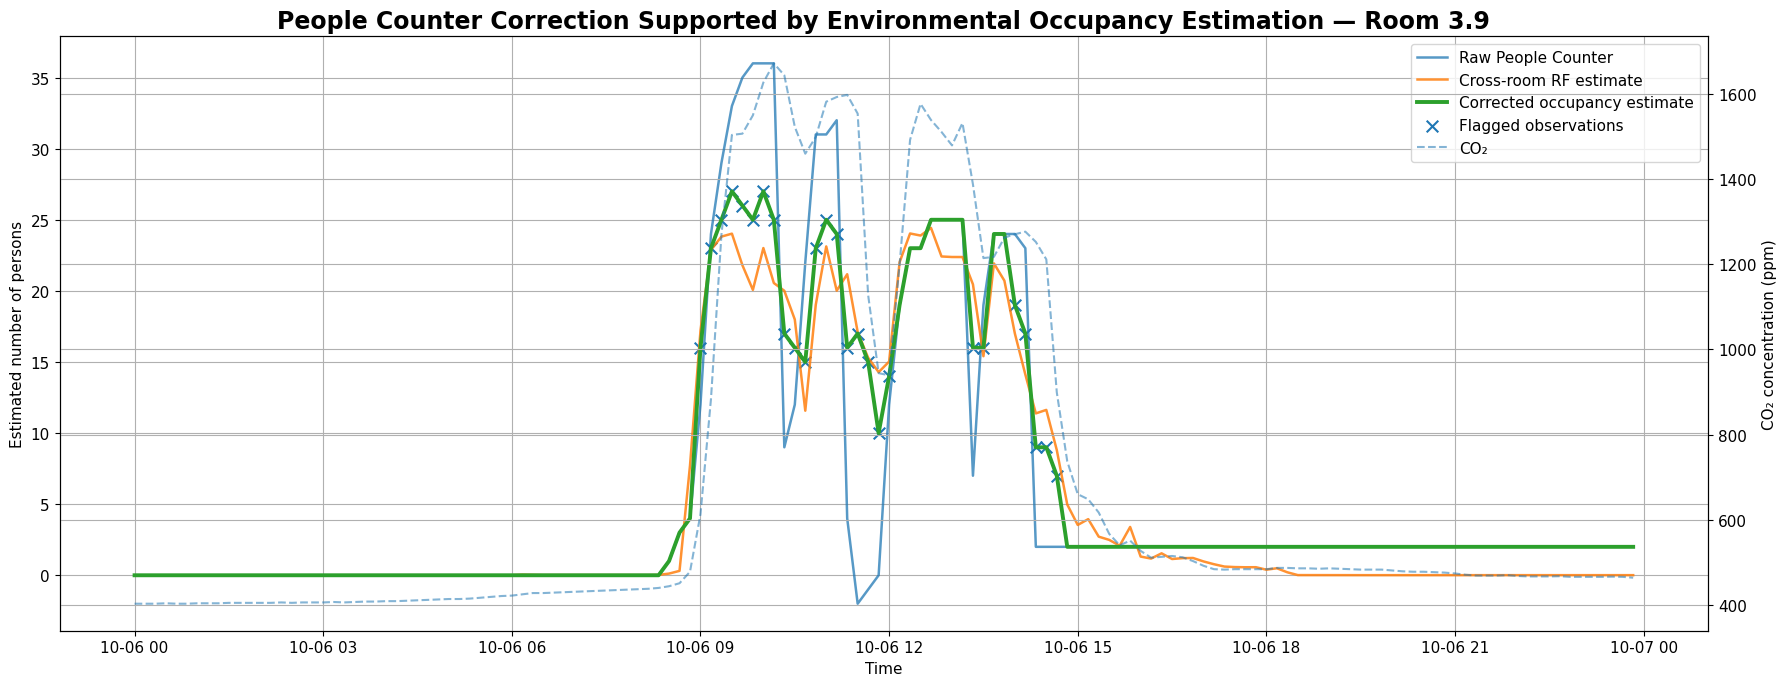

In [46]:
# FINAL CORRECTION EXAMPLE — ROOM 3.9


selected_day = "2025-10-06"

daily_example = comparison_39[
    comparison_39["ts"].dt.strftime("%Y-%m-%d")
    == selected_day
].copy()

fig, ax1 = plt.subplots(
    figsize=(18, 7)
)

ax1.plot(
    daily_example["ts"],
    daily_example["pc_occupancy_raw"],
    label="Raw People Counter",
    linewidth=1.8,
    alpha=0.75
)

ax1.plot(
    daily_example["ts"],
    daily_example["predicted_occupancy_rf"],
    label="Cross-room RF estimate",
    linewidth=1.8,
    alpha=0.85
)

ax1.plot(
    daily_example["ts"],
    daily_example["corrected_occupancy"],
    label="Corrected occupancy estimate",
    linewidth=2.8
)

flagged_points = daily_example[
    daily_example["inconsistency_flag"]
]

ax1.scatter(
    flagged_points["ts"],
    flagged_points["corrected_occupancy"],
    label="Flagged observations",
    marker="x",
    s=70
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Estimated number of persons")

# Secondary axis for CO₂ concentration
ax2 = ax1.twinx()

ax2.plot(
    daily_example["ts"],
    daily_example["co2_avg"],
    label="CO₂",
    linestyle="--",
    linewidth=1.5,
    alpha=0.55
)

ax2.set_ylabel("CO₂ concentration (ppm)")

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper right"
)

ax1.set_title(
    "People Counter Correction Supported by Environmental "
    "Occupancy Estimation — Room 3.9",
    fontsize=17,
    weight="bold"
)

fig.tight_layout()

fig.savefig(
    "Figure_ML_6_Corrected_Occupancy_Room_3_9.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correction Impact

The correction procedure is summarized by examining how frequently the raw People Counter estimate is modified and by quantifying the magnitude of the resulting corrections.

Flagged observations and modified observations are not necessarily identical, since a flagged observation may ultimately retain a value equivalent to the original estimate after the correction procedure is applied.

In [47]:
# ROOM 3.9 — CORRECTION IMPACT SUMMARY


comparison_39["correction_amount"] = (
    comparison_39["corrected_occupancy"]
    - comparison_39["pc_occupancy_raw"]
)

comparison_39["absolute_correction_amount"] = (
    comparison_39["correction_amount"].abs()
)

changed_mask = (
    comparison_39["corrected_occupancy"]
    != comparison_39["pc_occupancy_raw"]
)

correction_impact_summary = pd.DataFrame({
    "Metric": [
        "Total observations",
        "Observations with changed occupancy",
        "Percentage with changed occupancy",
        "Negative PC values replaced",
        "Mean absolute correction",
        "Median absolute correction",
        "Maximum absolute correction",
        "Corrections greater than 1 person",
        "Corrections greater than or equal to 5 persons"
    ],
    "Value": [
        len(comparison_39),
        int(changed_mask.sum()),
        round(100 * changed_mask.mean(), 2),
        int(comparison_39["negative_pc_flag"].sum()),
        round(
            comparison_39[
                "absolute_correction_amount"
            ].mean(),
            3
        ),
        round(
            comparison_39[
                "absolute_correction_amount"
            ].median(),
            3
        ),
        round(
            comparison_39[
                "absolute_correction_amount"
            ].max(),
            3
        ),
        int(
            (
                comparison_39[
                    "absolute_correction_amount"
                ] > 1
            ).sum()
        ),
        int(
            (
                comparison_39[
                    "absolute_correction_amount"
                ] >= 5
            ).sum()
        )
    ]
})

display(correction_impact_summary)

correction_impact_summary.to_csv(
    "room_3_9_correction_impact_summary.csv",
    index=False
)

print(
    "Saved: room_3_9_correction_impact_summary.csv"
)

,Metric,Value
0,Total observations,38304.000
1,Observations with changed occupancy,3892.000
2,Percentage with changed occupancy,10.160
3,Negative PC values replaced,2164.000
4,Mean absolute correction,0.385
5,Median absolute correction,0.000
6,Maximum absolute correction,21.000
7,Corrections greater than 1 person,2618.000
8,Corrections greater than or equal to 5 persons,1326.000


Saved: room_3_9_correction_impact_summary.csv


In [48]:
# SAVE FINAL ROOM 3.9 OCCUPANCY ESTIMATES


final_columns_39 = [
    "ts",
    "pc_occupancy_raw",
    "predicted_occupancy_rf",
    "corrected_occupancy",
    "co2_avg",
    "co2_change_10min",
    "temperature_avg",
    "humidity_avg",
    "open_windows",
    "negative_pc_flag",
    "large_jump_flag",
    "large_disagreement_flag",
    "inconsistency_flag"
]

comparison_39[
    final_columns_39
].to_csv(
    "room_3_9_corrected_occupancy.csv",
    index=False
)

print(
    "Room 3.9 correction completed successfully."
)

print(
    "Saved file: room_3_9_corrected_occupancy.csv"
)

Room 3.9 correction completed successfully.
Saved file: room_3_9_corrected_occupancy.csv


## 5. Scenario 1 Summary

Across both Room 4.9 and Room 2.3, Random Forest provided the strongest overall occupancy estimation performance among the evaluated approaches.

The results indicate that environmental measurements, particularly CO₂ dynamics and motion-related information, contain useful information about indoor occupancy. However, occupancy estimation during active periods remains more difficult than identifying low or zero occupancy.

In Room 3.9, the environmental occupancy estimate was therefore used as a supporting consistency signal rather than as direct ground truth. The resulting `corrected_occupancy` variable provides a more consistent operational estimate of room usage and is subsequently used as an input feature in the CO₂ forecasting scenario.